In [13]:
import pandas as pd
import numpy as np

In [14]:
import pandas as pd

df = pd.read_csv(
    "Indonesian-Twitter-Emotion-Dataset-master/Indonesian-Twitter-Emotion-Dataset-master/Twitter_Emotion_Dataset.csv"
)

df.head()

,label,tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."


In [15]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print(df['label'].value_counts())

(4401, 2)
Index(['label', 'tweet'], dtype='object')
label    0
tweet    0
dtype: int64
label
anger      1101
happy      1017
sadness     997
fear        649
love        637
Name: count, dtype: int64


In [16]:
print("Jumlah duplikat:", df.duplicated().sum())

df["tweet_length"] = df["tweet"].apply(len)

print("\nStatistik panjang tweet:")
print(df["tweet_length"].describe())

print("\nContoh tweet per label:")
for label in df["label"].unique():
    print(f"\nLabel: {label}")
    print(df[df["label"] == label]["tweet"].iloc[0])

Jumlah duplikat: 11

Statistik panjang tweet:
count    4401.000000
mean      182.352193
std        55.697054
min        12.000000
25%       147.000000
50%       178.000000
75%       226.000000
max       500.000000
Name: tweet_length, dtype: float64

Contoh tweet per label:

Label: anger
Soal jln Jatibaru,polisi tdk bs GERTAK gubernur .Emangny polisi tdk ikut pmbhasan? Jgn berpolitik. Pengaturan wilayah,hak gubernur. Persoalan Tn Abang soal turun temurun.Pelik.Perlu kesabaran. [USERNAME] [USERNAME] [URL]

Label: happy
Kepingin gudeg mbarek Bu hj. Amad Foto dari google, sengaja, biar teman-teman jg membayangkannya. Berbagi itu indah.

Label: sadness
Orang lain kalau pake ponco itu buat jas hujan, nah dia pake buat kasur. Ya tadi gara2 saking gak punya apa2. Mamak bilang, kami tuh di awal pernikan gak ada ngalamin bulan madu kayak skrg2. Org tidur nya aja pake ponco. Gimane mau bulan madu.

Label: love
Setiap kesempatan yg pernah hadir tuk dapat membuatmu selalu merasa aman dan nyaman, ki

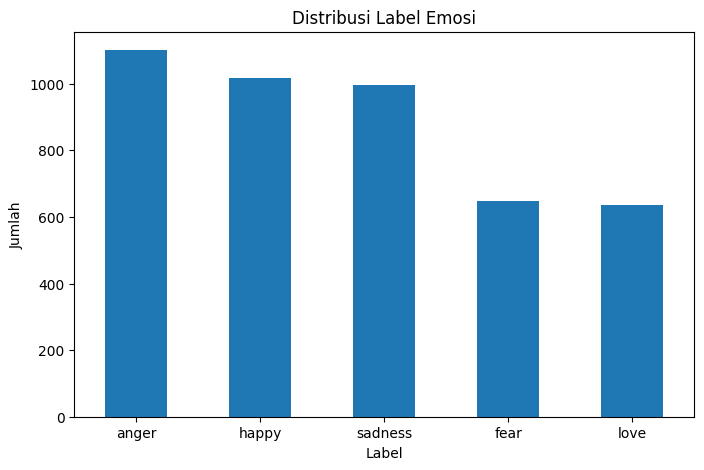

In [17]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()

plt.figure(figsize=(8,5))
label_counts.plot(kind="bar")
plt.title("Distribusi Label Emosi")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

In [18]:
df = df.drop_duplicates().reset_index(drop=True)

print("after hapus duplikat:", df.shape)
print(df["label"].value_counts())

after hapus duplikat: (4390, 3)
label
anger      1100
happy      1012
sadness     996
fear        646
love        636
Name: count, dtype: int64


In [19]:
# Cleaning dasar
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[username\]', ' username ', text)
    text = re.sub(r'\[url\]', ' url ', text)
    text = re.sub(r'\[sensitive-no\]', ' sensitive_no ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_tweet"] = df["tweet"].apply(clean_text)

print(df[["tweet", "clean_tweet"]].head())

                                               tweet  \
0  Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...   
1  Sesama cewe lho (kayaknya), harusnya bisa lebi...   
2  Kepingin gudeg mbarek Bu hj. Amad Foto dari go...   
3  Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...   
4  Sharing pengalaman aja, kemarin jam 18.00 bata...   

                                         clean_tweet  
0  soal jln jatibaru polisi tdk bs gertak gubernu...  
1  sesama cewe lho kayaknya harusnya bisa lebih r...  
2  kepingin gudeg mbarek bu hj amad foto dari goo...  
3  jln jatibaru bagian dari wilayah tn abang peng...  
4  sharing pengalaman aja kemarin jam batalin tik...  


In [20]:
# Encode label
label_mapping = {
    "anger": 0,
    "fear": 1,
    "happy": 2,
    "love": 3,
    "sadness": 4
}

df["label_encoded"] = df["label"].map(label_mapping)

print(df[["label", "label_encoded"]].head())
print(df["label_encoded"].value_counts())

   label  label_encoded
0  anger              0
1  anger              0
2  happy              2
3  anger              0
4  happy              2
label_encoded
0    1100
2    1012
4     996
1     646
3     636
Name: count, dtype: int64


In [21]:
# Split data
from sklearn.model_selection import train_test_split

X = df["clean_tweet"]
y = df["label_encoded"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 3512
Validation: 439
Test: 439


In [22]:
# Class Weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{0: 0.7981818181818182, 1: 1.3586073500967117, 2: 0.8682323856613102, 3: 1.379960707269155, 4: 0.8813048933500628}


In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
maxlen = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=maxlen, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding="post", truncating="post")

print("Shape X_train_pad:", X_train_pad.shape)
print("Shape X_val_pad:", X_val_pad.shape)
print("Shape X_test_pad:", X_test_pad.shape)

Shape X_train_pad: (3512, 100)
Shape X_val_pad: (439, 100)
Shape X_test_pad: (439, 100)


C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2153 - loss: 1.6197 - val_accuracy: 0.1708 - val_loss: 1.6187
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2207 - loss: 1.6116 - val_accuracy: 0.1686 - val_loss: 1.6194
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2087 - loss: 1.6095 - val_accuracy: 0.2187 - val_loss: 1.6146
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2269 - loss: 1.6168 - val_accuracy: 0.2232 - val_loss: 1.6111
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1993 - loss: 1.6242 - val_accuracy: 0.1959 - val_loss: 1.6108
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2013 - loss: 1.6216 - val_accuracy: 0.2073 - val_loss: 1.6108
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2016 - loss: 1.6179 - val_accuracy: 0.2141 - val_loss: 1.6134
Epoch 8/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1896 - loss: 1.6131 - val_accu

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

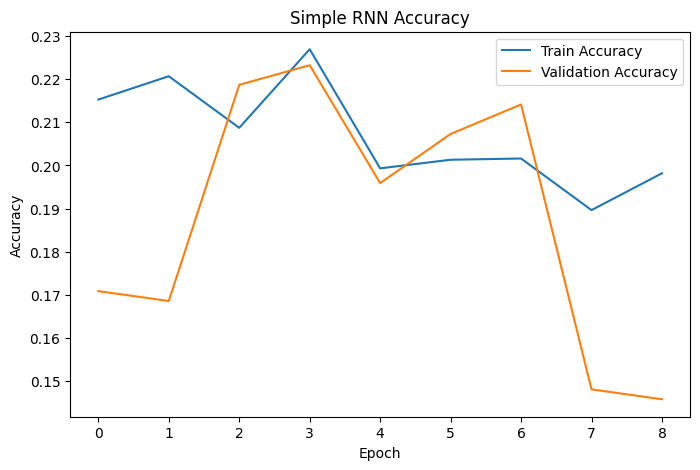

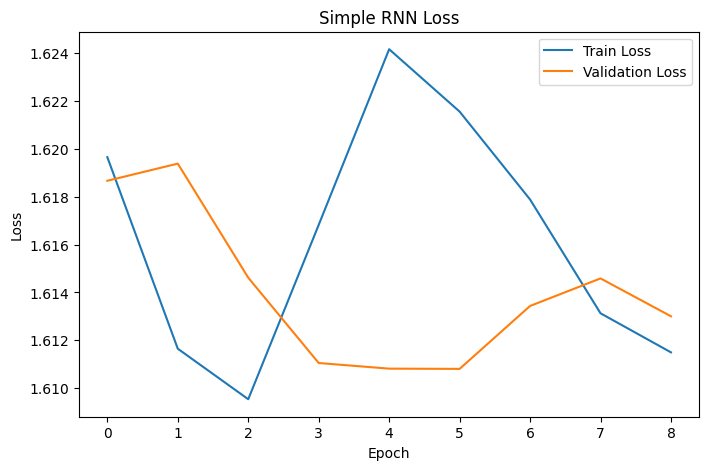


Ringkasan hasil:
[{'Model': 'Simple RNN', 'Accuracy': 0.214123006833713, 'Precision': 0.17185608278203854, 'Recall': 0.1993663116311631, 'F1-score': 0.17153628389817815}]


C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [24]:
# Simple RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

num_classes = 5

model_rnn = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=maxlen),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

test_loss, test_acc = model_rnn.evaluate(X_test_pad, y_test, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_pred_prob = model_rnn.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

label_names = ['anger', 'fear', 'happy', 'love', 'sadness']

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Simple RNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro'
)

results = []
results.append({
    "Model": "Simple RNN",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

print("\nRingkasan hasil:")
print(results)

In [25]:
results = []

In [26]:
def evaluate_model(model, history, X_test_pad, y_test, model_name, results):
    test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"\n=== {model_name} ===")
    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_acc)

    y_pred_prob = model.predict(X_test_pad)
    y_pred = np.argmax(y_pred_prob, axis=1)

    label_names = ['anger', 'fear', 'happy', 'love', 'sadness']

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    return results

In [27]:
from tensorflow.keras.layers import LSTM, GRU, Bidirectional
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [28]:
# FUNGSI EVALUASI
def evaluate_model(model, history, X_test_pad, y_test, model_name, results):
    test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"\n=== {model_name} ===")
    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_acc)

    y_pred_prob = model.predict(X_test_pad)
    y_pred = np.argmax(y_pred_prob, axis=1)

    label_names = ['anger', 'fear', 'happy', 'love', 'sadness']

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    return results

In [29]:
# EARLY STOPPING
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

LSTM

In [30]:
model_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=maxlen),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.2298 - loss: 1.6112 - val_accuracy: 0.2278 - val_loss: 1.6095
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.2212 - loss: 1.6103 - val_accuracy: 0.2506 - val_loss: 1.6069
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1828 - loss: 1.6109 - val_accuracy: 0.1435 - val_loss: 1.6107
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.1902 - loss: 1.6104 - val_accuracy: 0.2278 - val_loss: 1.6047
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.1834 - loss: 1.6103 - val_accuracy: 0.2278 - val_loss: 1.6067
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1785 - loss: 1.6100 - val_accuracy: 0.2506 - val_loss: 1.6055
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.2175 - loss: 1.6103 - val_accuracy: 0.1458 - val_loss: 1.6107



=== LSTM ===
Test Loss: 1.604926347732544
Test Accuracy: 0.2255125343799591
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Classification Report:
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       110
        fear       0.00      0.00      0.00        65
       happy       0.00      0.00      0.00       101
        love       0.00      0.00      0.00        64
     sadness       0.23      1.00      0.37        99

    accuracy                           0.23       439
   macro avg       0.05      0.20      0.07       439
weighted avg       0.05      0.23      0.08       439


Confusion Matrix:
[[  0   0   0   0 110]
 [  0   0   0   0  65]
 [  0   0   0   0 101]
 [  0   0   0   0  64]
 [  0   0   0   0  99]]


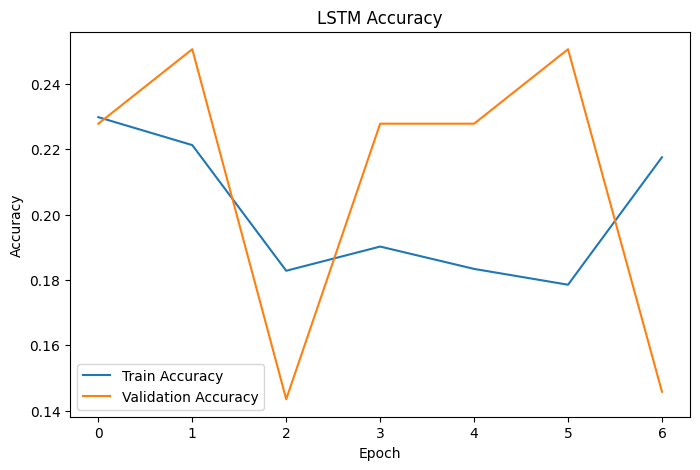

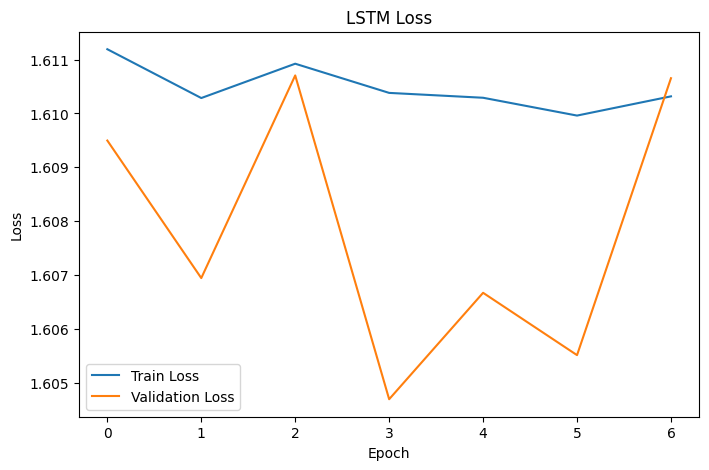

In [32]:
results = evaluate_model(model_lstm, history_lstm, X_test_pad, y_test, "LSTM", results)

GRU

In [33]:
model_gru = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=maxlen),
    GRU(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_gru = model_gru.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.1962 - loss: 1.6117 - val_accuracy: 0.2323 - val_loss: 1.6046
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2002 - loss: 1.6108 - val_accuracy: 0.1458 - val_loss: 1.6194
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1956 - loss: 1.6104 - val_accuracy: 0.1435 - val_loss: 1.6150
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1731 - loss: 1.6107 - val_accuracy: 0.2278 - val_loss: 1.6097



=== GRU ===
Test Loss: 1.6049004793167114
Test Accuracy: 0.23006834089756012
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report:
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       110
        fear       0.00      0.00      0.00        65
       happy       0.23      1.00      0.37       101
        love       0.00      0.00      0.00        64
     sadness       0.00      0.00      0.00        99

    accuracy                           0.23       439
   macro avg       0.05      0.20      0.07       439
weighted avg       0.05      0.23      0.09       439


Confusion Matrix:
[[  0   0 110   0   0]
 [  0   0  65   0   0]
 [  0   0 101   0   0]
 [  0   0  64   0   0]
 [  0   0  99   0   0]]


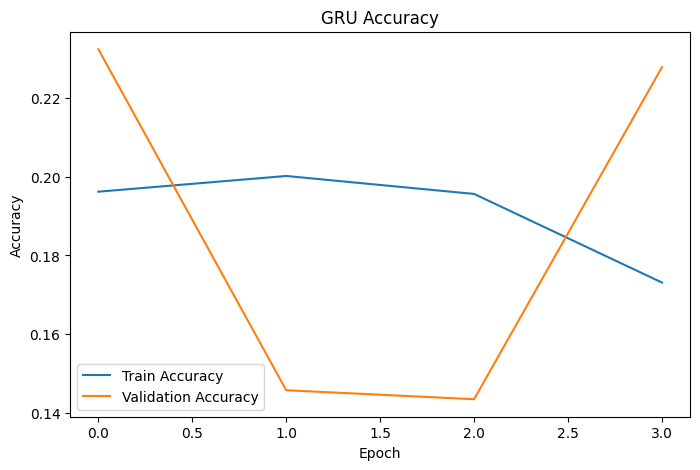

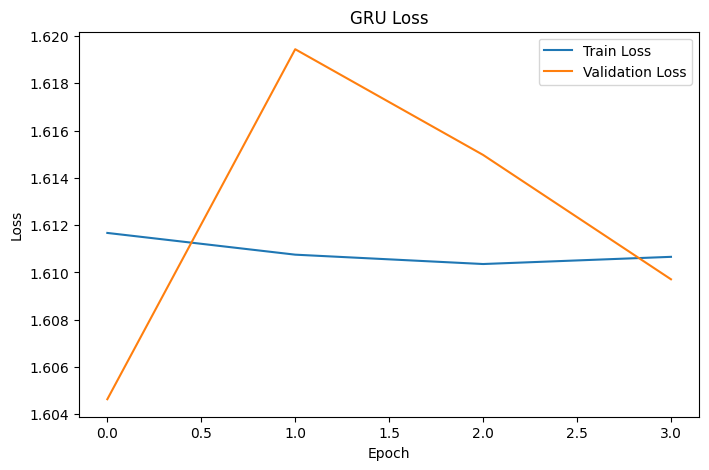

In [35]:
results = evaluate_model(model_gru, history_gru, X_test_pad, y_test, "GRU", results)

BiLSTM

In [36]:
model_bilstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=maxlen),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_bilstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_bilstm.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
history_bilstm = model_bilstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.3366 - loss: 1.4797 - val_accuracy: 0.4237 - val_loss: 1.3033
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6543 - loss: 0.8654 - val_accuracy: 0.5353 - val_loss: 1.1820
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8445 - loss: 0.4620 - val_accuracy: 0.5604 - val_loss: 1.5168
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9274 - loss: 0.2411 - val_accuracy: 0.5626 - val_loss: 1.8469
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9650 - loss: 0.1259 - val_accuracy: 0.5604 - val_loss: 1.9929



=== BiLSTM ===
Test Loss: 1.0467389822006226
Test Accuracy: 0.6082004308700562
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classification Report:
              precision    recall  f1-score   support

       anger       0.63      0.73      0.68       110
        fear       0.67      0.72      0.70        65
       happy       0.53      0.62      0.58       101
        love       0.73      0.62      0.67        64
     sadness       0.53      0.37      0.44        99

    accuracy                           0.61       439
   macro avg       0.62      0.61      0.61       439
weighted avg       0.61      0.61      0.60       439


Confusion Matrix:
[[80  7 12  0 11]
 [11 47  4  1  2]
 [18  1 63  3 16]
 [ 0  3 17 40  4]
 [17 12 22 11 37]]


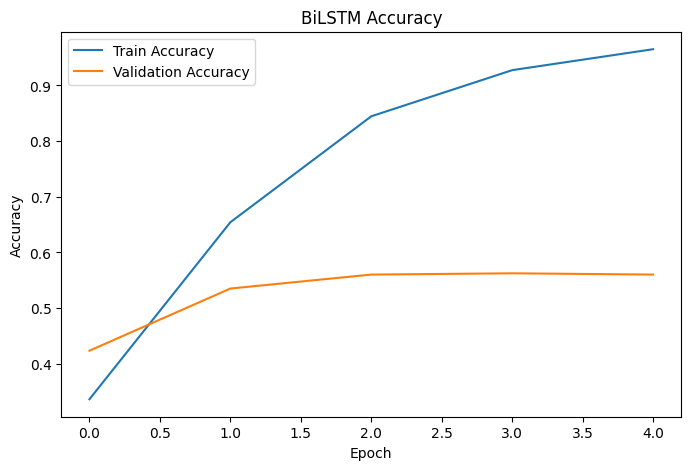

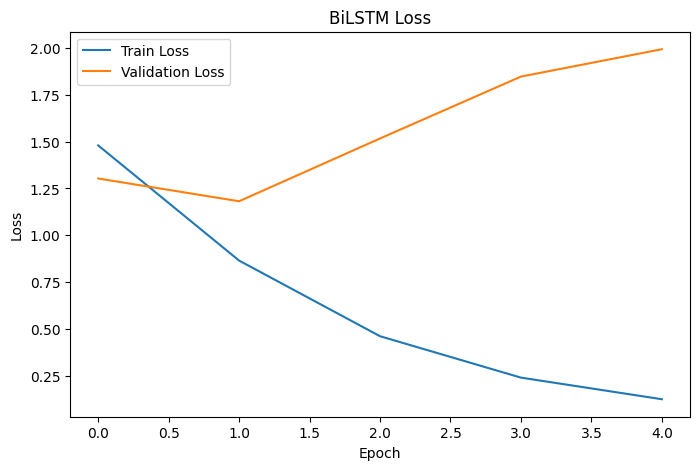

In [38]:
results = evaluate_model(model_bilstm, history_bilstm, X_test_pad, y_test, "BiLSTM", results)

BiGRU

In [39]:
model_bigru = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=maxlen),
    Bidirectional(GRU(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_bigru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_bigru.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
history_bigru = model_bigru.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.3013 - loss: 1.5395 - val_accuracy: 0.3941 - val_loss: 1.3588
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5809 - loss: 1.0238 - val_accuracy: 0.5103 - val_loss: 1.2338
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7833 - loss: 0.5521 - val_accuracy: 0.5171 - val_loss: 1.4058



=== BiGRU ===
Test Loss: 1.324381947517395
Test Accuracy: 0.42596811056137085
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

Classification Report:
              precision    recall  f1-score   support

       anger       0.47      0.72      0.57       110
        fear       0.28      0.52      0.37        65
       happy       0.50      0.15      0.23       101
        love       0.67      0.70      0.69        64
     sadness       0.26      0.14      0.18        99

    accuracy                           0.43       439
   macro avg       0.44      0.45      0.41       439
weighted avg       0.43      0.43      0.39       439


Confusion Matrix:
[[79 22  1  1  7]
 [21 34  3  1  6]
 [35 22 15 11 18]
 [ 1  8  2 45  8]
 [33 34  9  9 14]]


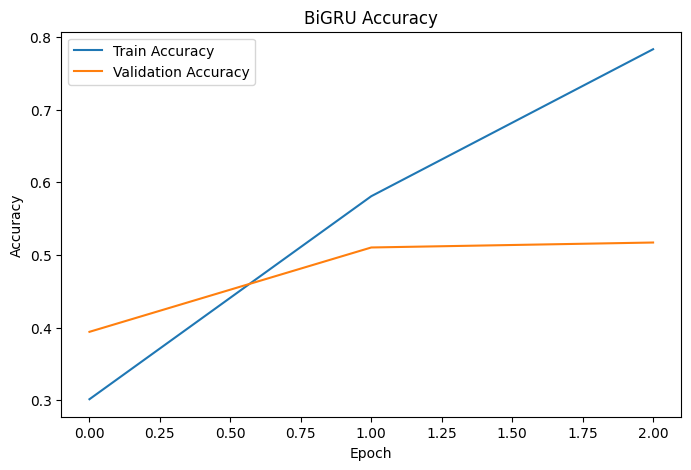

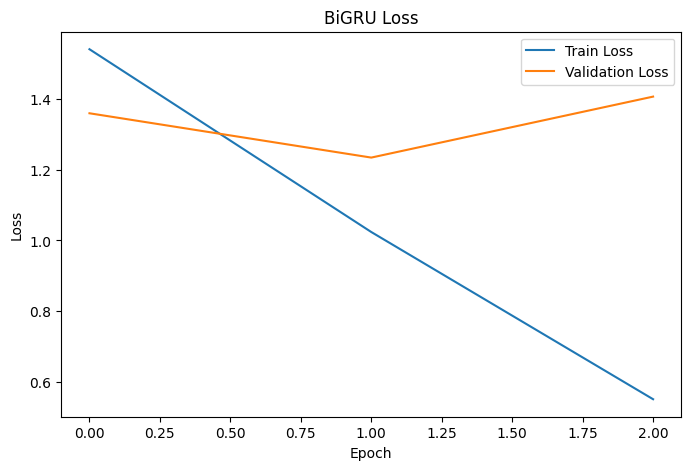

In [41]:
results = evaluate_model(model_bigru, history_bigru, X_test_pad, y_test, "BiGRU", results)

HASIL AKHIR

In [42]:
results.append({
    "Model": "Simple RNN",
    "Accuracy": 0.255125284738041,
    "Precision": 0.25034324942791764,
    "Recall": 0.20396039603960398,
    "F1-score": 0.088205747146838
})

In [43]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,BiLSTM,0.608200,0.619218,0.614570,0.611949
1,BiGRU,0.425968,0.437316,0.446863,0.406823
2,Simple RNN,0.255125,0.250343,0.203960,0.088206
3,GRU,0.230068,0.046014,0.200000,0.074815
4,LSTM,0.225513,0.045103,0.200000,0.073606
